# Pachete necesare pentru folosirea acestui Notebook

Vom folosi [scipy](https://scipy.org/), [numpy](https://numpy.org/) si [matplotlib](https://matplotlib.org/).

In [ ]:
from scipy import misc, ndimage
import numpy as np
import matplotlib.pyplot as plt

# Imaginea cu care lucrÄm

Vom folosi o imagine din setul de date oferit implicit de cÄtre scipy.

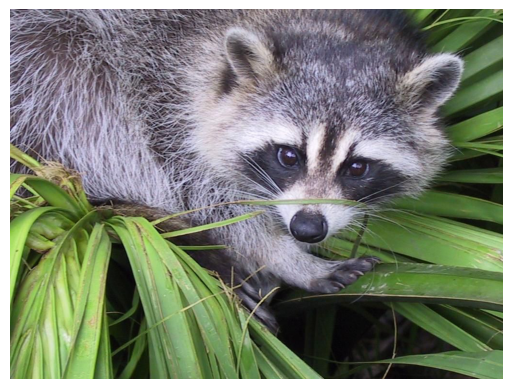

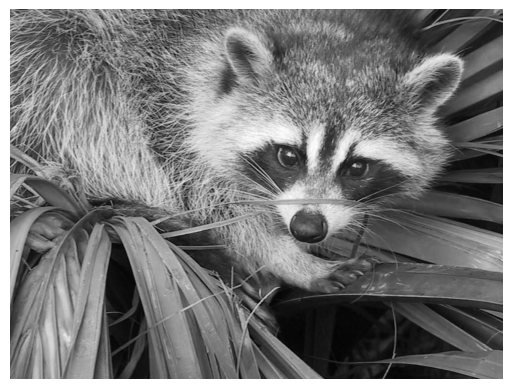

In [4]:
# X = misc.face(gray=True)
# plt.imshow(X, cmap=plt.cm.gray)
# plt.show()

# import scipy
# print(scipy.__version__) #1.15.3

import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt

X = imageio.imread("racoon.png") # COLOR
plt.imshow(X)
plt.axis("off")
plt.show()

gray = np.mean(X, axis=2)          # GRI = media celor 3 canale de culoare duce la grayscale
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

#In practica: Gray = 0.299 * R + 0.587 * G + 0.114 * B


# Transformata Fourier a unei imagini

Transformata Fourier DiscretÄ se extinde uČor la mai multe dimensiuni. Pentru un semnal bidimensional precum o imagine DFT devine:

$$
Y_{m_1,m_2} = \sum_{n_1=0}^{N_1-1}\sum_{n_2=0}^{N_2-1}x_{n_1,n_2}e^{-j2\pi(m_1 n_1/N_1 + m_2 n_2/N_2)}
$$

* unde $n_1$ Či $n_2$ sunt poziČile pixelilor pe orizontalÄ, respectiv, pe verticalÄ
* bin-urile rezultate corespund poziČiilor pixelilor
* spectrul este ĂŽn continuare simetric
* proprietÄČile transformatei DFT 1D sunt respectate Či ĂŽn cazul celei 2D

Ăn continuare vom folosi rutina generalÄ `fft2` ce serveČte mai bine activitÄČii de ĂŽnvÄČare, deČi pentru semnale reale ar trebui sÄ folosim `rfft2` ce ĂŽntoarce doar informaČia esenČialÄ (ex. omite simetriile). De asemenea vom analiza spectrul ĂŽn scalÄ logaritmicÄ pentru a diferenČia mai bine magnitudinile bin-urilor DTF.

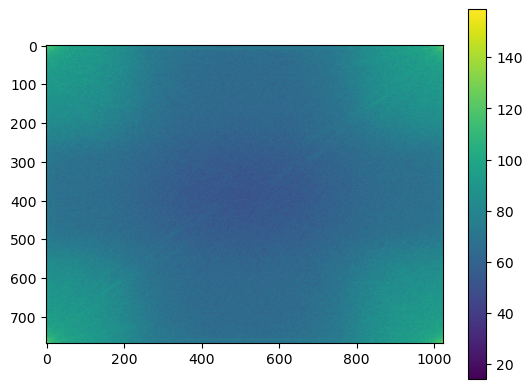

In [19]:
Y = np.fft.fft2(gray)
freq_db = 20*np.log10(abs(Y))

plt.imshow(freq_db)
plt.colorbar()
plt.show()

OperaČiile efectuate direct asupra imaginii se reflectÄ Či ĂŽn spectrul acesteia. IatÄ un exemplu a unei rotaČii de 45 de grade:

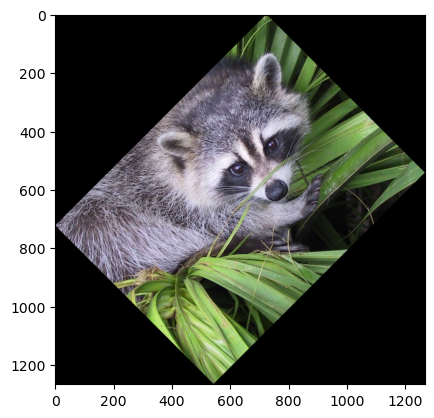

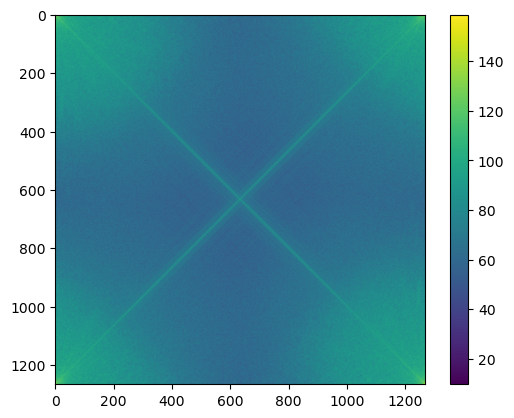

In [21]:
rotate_angle = 45
X45 = ndimage.rotate(X, rotate_angle)
plt.imshow(X45, cmap=plt.cm.gray)
plt.show()

X45_gray = np.mean(X45, axis=2) 

Y45 = np.fft.fft2(X45_gray)
plt.imshow(20*np.log10(abs(Y45)))
plt.colorbar()
plt.show()

Momentan pe axe sunt afiČate numÄrul bin-urilor. Pentru a obČine frecvenČele asociate folosiČi `fftfreq`:

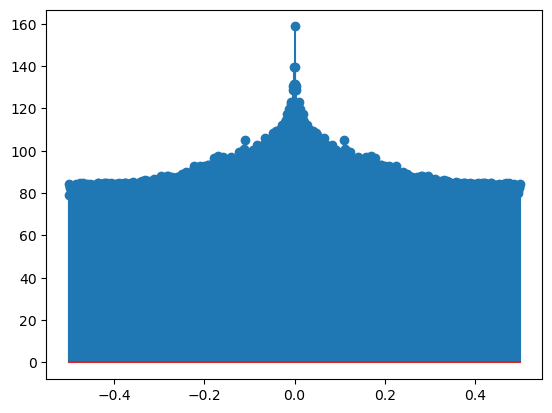

In [24]:
freq_x = np.fft.fftfreq(X.shape[1])
freq_y = np.fft.fftfreq(X.shape[0])

plt.stem(freq_x, freq_db[:][0])
plt.show()

# Atenuarea frecvenČelor ĂŽnalte

Pentru a anula frecvenČele de peste un anumit prag `freq_cutoff` putem pur Či simplu anula intrÄrile din spectru Či aplica transformata Fourier inversÄ:

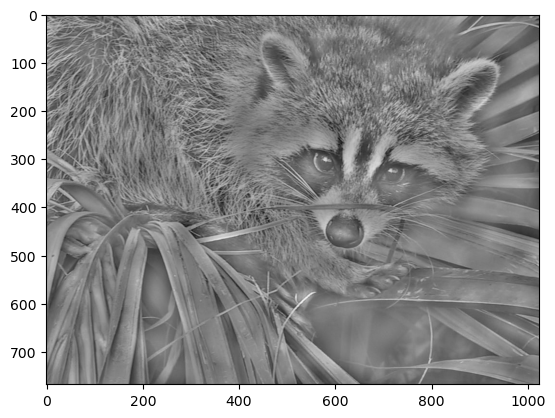

In [ ]:
freq_cutoff = 120

Y_cutoff = Y.copy()
Y_cutoff[freq_db > freq_cutoff] = 0 #unde magnitudinea în dB e MAI MARE decât pragul, pune 0 în spectru
                                    #elimină componentele cu energie mare (în general frecvențele joase, mai ales DC)
X_cutoff = np.fft.ifft2(Y_cutoff)
X_cutoff = np.real(X_cutoff)    # avoid rounding erros in the complex domain,
                                # in practice use irfft2
plt.imshow(X_cutoff, cmap=plt.cm.gray)
plt.show()

# Zgomot

Zgomotul alb perturbÄ ĂŽn mod egal spectrul semnalului. Este astfel egal distribuit Či regÄsit ĂŽn toate bin-urile DFT. [Zgomotul color](https://en.wikipedia.org/wiki/Colors_of_noise) se schimbÄ de-a lungul frecvenČelor.

Putem adÄuga zgomot ĂŽn limita a `pixel_noise` pixeli imaginii folosind `random.randint`:

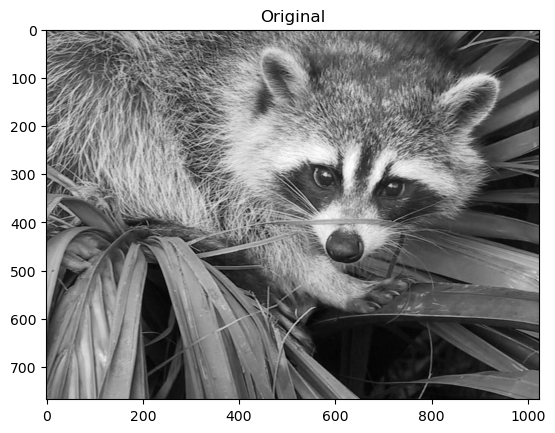

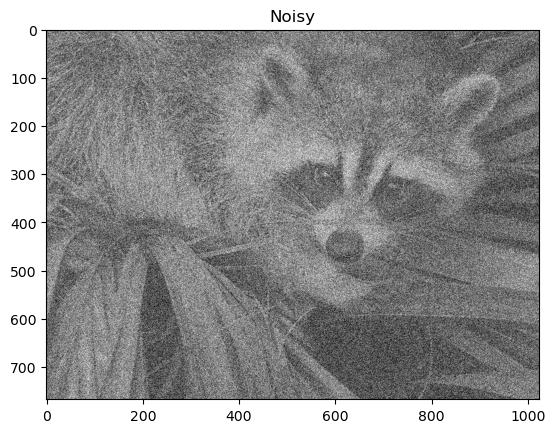

In [5]:
pixel_noise = 200
X = np.mean(X, axis=2)          # GRI

noise = np.random.randint(-pixel_noise, high=pixel_noise+1, size=X.shape)
X_noisy = X + noise
plt.imshow(X, cmap=plt.cm.gray)
plt.title('Original')
plt.show()
plt.imshow(X_noisy, cmap=plt.cm.gray)
plt.title('Noisy')
plt.show()

# Sarcini

1. ProduceČi imaginile Či spectrul pentru funcČiile de mai jos Či daČi o explicaČie scurtÄ pentru fiecare rezultat.
* $x_{n_1,n_2} = \sin(2\pi n_1 + 3\pi n_2)$
* $x_{n_1,n_2} = \sin(4\pi n_1) + \cos(6\pi n_2)$
* $Y_{0,5} = Y_{0,N-5} = 1\text{, altfel }Y_{m_1,m_2} = 0,\ \forall m_1, m_2$
* $Y_{5,0} = Y_{N-5,0} = 1\text{, altfel }Y_{m_1,m_2} = 0,\ \forall m_1, m_2$
* $Y_{5,5} = Y_{N-5,N-5} = 1\text{, altfel }Y_{m_1,m_2} = 0,\ \forall m_1, m_2$

*AtenČie*: $x$ reprezintÄ informaČie ĂŽn domeniul timpului, $Y$ ĂŽn domeninul frecvenČei.

2. ComprimaČi imaginea cu ratonul de mai sus prin atenuarea frecvenČelor ĂŽnalte pĂ˘nÄ la un prag SNR autoimpus.

3. EliminaČi zgomotul adÄugat la imaginea cu ratonul produsÄ mai sus. PrezentaČi raportul SNR ĂŽnainte Či dupÄ.

[[ 0  0  0 ...  0  0  0]
 [ 1  1  1 ...  1  1  1]
 [ 2  2  2 ...  2  2  2]
 ...
 [61 61 61 ... 61 61 61]
 [62 62 62 ... 62 62 62]
 [63 63 63 ... 63 63 63]]
[[ 0  1  2 ... 61 62 63]
 [ 0  1  2 ... 61 62 63]
 [ 0  1  2 ... 61 62 63]
 ...
 [ 0  1  2 ... 61 62 63]
 [ 0  1  2 ... 61 62 63]
 [ 0  1  2 ... 61 62 63]]


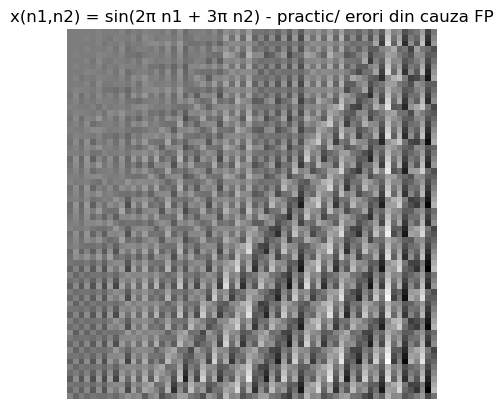

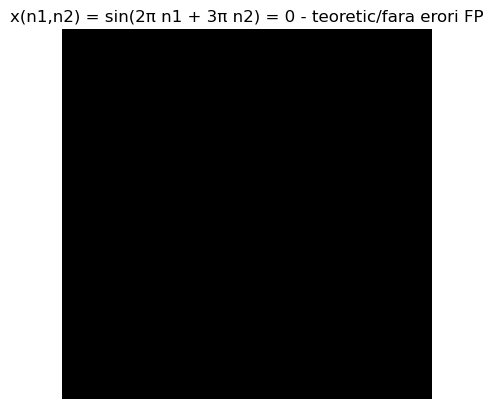

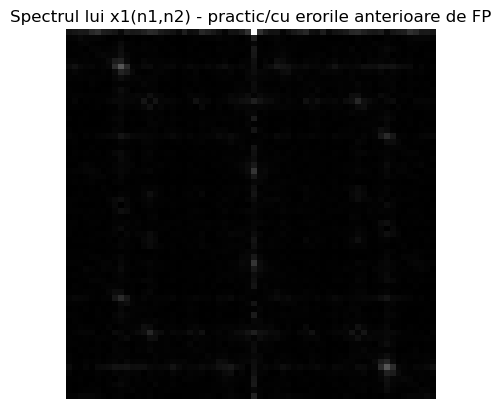

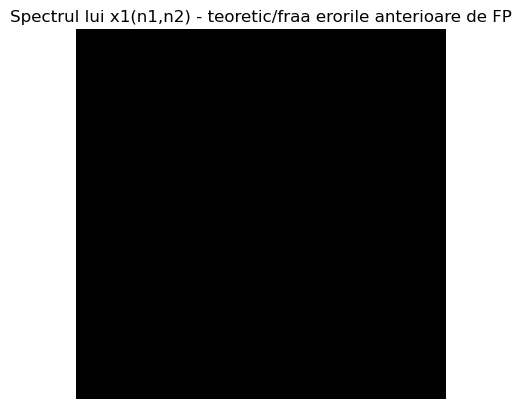

In [ ]:
#1. 

#PRIMA BULINA sin(2 pi n1+3 pi n2) = (de fapt) =  sin( 3 pi n2 + multiplu de 2pi) = sin(3 pi n2) = sin( multiplu de pi) = 0

def x1(n1,n2):
    return np.sin(2*np.pi*n1 + 3*np.pi * n2)

N = 64 #generez un semnal de 64 x 64

n1 = np.arange(N) # esantioanele pe axa orizontala 
# print(n1)
n2 = np.arange(N) # esantioanele pe axa verticala 

n1g, n2g = np.meshgrid(n1, n2, indexing='ij') #returneaza doua matrici 2D, construite din vectorii de intrare 
                                                    # prin replicarea primului pe linii si a celui de-al doilea pe coloane
print(n1g) # matrice cu vectorul n1 repetat pe linii de 64 de ori
print(n2g) # matrice cu vectorul n2 repetat pe linii de 64 de ori

# 2D (meshgrid)
# meshgrid ia vectorii 1D si creeaza doi tensor-matrici de dimensiune 64 x 64


# n1g conține pe fiecare coloană același vector n1
# n2g conține pe fiecare linie același vector n2

x = x1(n1g, n2g)

plt.imshow(x, cmap='gray')
plt.title("x(n1,n2) = sin(2π n1 + 3π n2) - practic/ erori din cauza FP")
plt.axis('off')
plt.savefig("1_a_practic.pdf")
plt.show()

#TEORETIC:
x_teoretic = np.zeros((N, N))
plt.imshow(x_teoretic, cmap='gray')
plt.title("x(n1,n2) = sin(2π n1 + 3π n2) = 0 - teoretic/fara erori FP")
plt.axis('off')
plt.savefig("1_a_teoretic.pdf")
plt.show()

#spectru
X = np.fft.fft2(x)

plt.imshow(np.abs(X), cmap='gray')
plt.title("Spectrul lui x1(n1,n2) - practic/cu erorile anterioare de FP")
plt.axis('off')
plt.savefig("1_a_practic_spectru.pdf")
plt.show()

#spectru pentru x_teoretic:
X_teoretic = np.fft.fft2(x_teoretic)

plt.imshow(np.abs(X_teoretic), cmap='gray')
plt.title("Spectrul lui x1(n1,n2) - teoretic/fraa erorile anterioare de FP")
plt.axis('off')
plt.savefig("1_a_teoretic_spectru.pdf")
plt.show()


#COMENTARII:

#Pentru un semnal care e peste tot 0, transformata sa Fourier e peste tot 0. 
# X[m1, m2] = 0, orice m1, m2 daca x[m1,m2] = 0

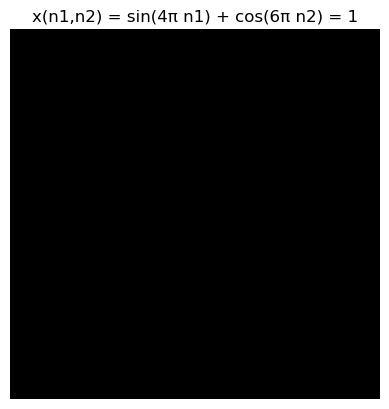

[[4096.+0.j    0.+0.j    0.+0.j ...    0.+0.j    0.+0.j    0.+0.j]
 [   0.+0.j    0.+0.j    0.+0.j ...    0.+0.j    0.+0.j    0.+0.j]
 [   0.+0.j    0.+0.j    0.+0.j ...    0.+0.j    0.+0.j    0.+0.j]
 ...
 [   0.+0.j    0.+0.j    0.+0.j ...    0.+0.j    0.+0.j    0.+0.j]
 [   0.+0.j    0.+0.j    0.+0.j ...    0.+0.j    0.+0.j    0.+0.j]
 [   0.+0.j    0.+0.j    0.+0.j ...    0.+0.j    0.+0.j    0.+0.j]]


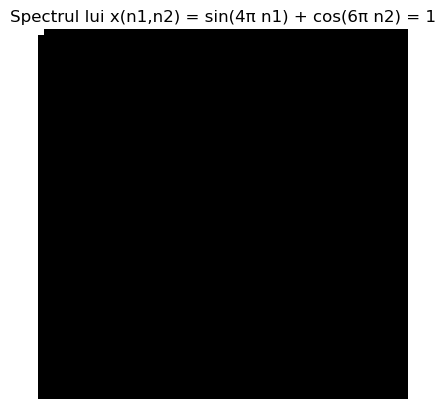

In [ ]:
# A DOUA BULINA

def x2(n1, n2):
    return np.sin(4*np.pi*n1) + np.cos(6*np.pi*n2)

# Obs: sin(4 pi n1) = sin( multiplu de 2pi) = 0
#      cos(6 pi n2) = cos( multiplu de 2pi) = cos 0 = 1

# Deci x(n1, n2) = 1, orice n1, n2

x = np.ones((N, N))

plt.imshow(x, cmap='gray')
plt.title("x(n1,n2) = sin(4π n1) + cos(6π n2) = 1")
plt.axis('off')
plt.savefig("1_b.pdf")
plt.show()

#spectru
X = np.fft.fft2(x)
print(X)

plt.imshow(np.abs(X), cmap='gray')
plt.title("Spectrul lui x(n1,n2) = sin(4π n1) + cos(6π n2) = 1")
plt.axis('off')
plt.savefig("1_b_spectru.pdf")
plt.show()

#COMENTARII:

# Semnalul e constant, mereu egal cu 1
# Imaginea e o matrice uniforma, de culoare foarte apropiata de negru (negru = 0, alb = 255)

# Transformata Fourier a unei imagini constante contine doar componenta DC (binul 0,0 = alb). Restul spectrului este 0.
# X[0,0] = N * N * 1 = 64 * 64 * 1 = 4096 = suma tuturor pixelilor din imagine
#                                    Daca normalizez si impart la N*N => media semnalului


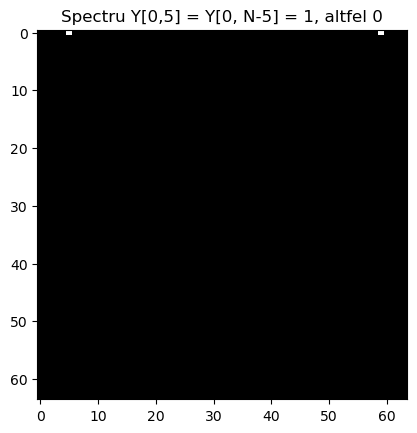

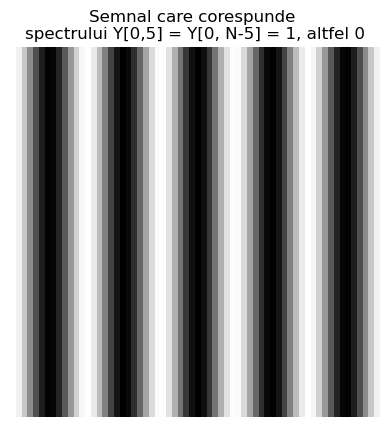

In [ ]:
# A TREIA BULINA

Y = np.zeros((N, N))
Y[0,5] = 1
Y[0, N-5] = 1

plt.imshow(np.abs(Y), cmap='gray')
plt.title("Spectru Y[0,5] = Y[0, N-5] = 1, altfel 0")
# plt.axis('off')
plt.savefig("1_c_spectru.pdf")
plt.show()

x = np.fft.ifft2(Y)
x = np.real(x)

plt.imshow(x, cmap='gray')
plt.title("Semnal care corespunde \nspectrului Y[0,5] = Y[0, N-5] = 1, altfel 0")
plt.axis('off')
plt.savefig("1_c_semnal.pdf")
plt.show()

#COMENTARII:

# in Y am activat doar 2 binuri din spectrul 2D

# cum Y[m1, m2] = Y*[N1-m1, N2-m2] (AICI: Y[0,5] = Y*[0, N-5]), practic am activat o singura frecventa 2D, (m1, m2) = (0, +/-5)
# Asta inseamna ca in imaginea obtinuta cu ifft, m1 = 0 imi spune ca nu voi avea nicio variatie pe directia parcursa de n1 (nicio variatie pe linii, pe orizontala)
#                                                m2 = 5 imi spune ca voi avea o variatie pe directia parcursa de n2 (pe coloane, pe verticala)
#                                            frecventa acestei variatii e de 5 cicluri/lungimea imaginii

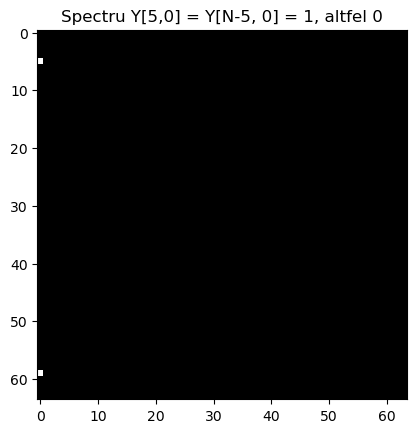

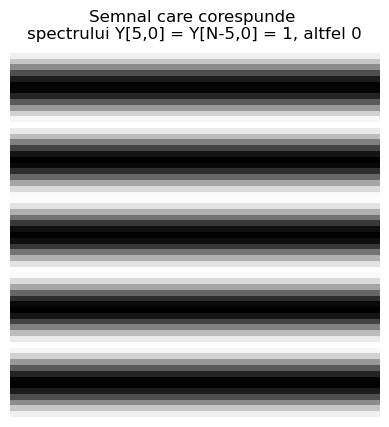

In [17]:
# A PATRA BULINA

Y = np.zeros((N, N))
Y[5,0] = 1
Y[N-5,0] = 1

plt.imshow(np.abs(Y), cmap='gray')
plt.title("Spectru Y[5,0] = Y[N-5, 0] = 1, altfel 0")
# plt.axis('off')
plt.savefig("1_d_spectru.pdf")
plt.show()

x = np.fft.ifft2(Y)
x = np.real(x)

plt.imshow(x, cmap='gray')
plt.title("Semnal care corespunde \nspectrului Y[5,0] = Y[N-5,0] = 1, altfel 0")
plt.axis('off')
plt.savefig("1_d_semnal.pdf")
plt.show()

#COMENTARII:

# in Y am activat doar 2 binuri din spectrul 2D

# cum Y[m1, m2] = Y*[N1-m1, N2-m2] (AICI: Y[5,0] = Y*[N-5, 0]), practic am activat o singura frecventa 2D, (m1, m2) = (5, 0)
# Asta inseamna ca in imaginea obtinuta cu ifft, m2 = 0 imi spune ca NU voi avea nicio variatie pe directia parcursa de n2 (nicio variatie pe coloane, pe verticala)
#                                                m1 = 5 imi spune ca voi avea o variatie pe directia parcursa de n1 (pe linii, pe orizontala)
#                                            frecventa acestei variatii e de 5 cicluri de a lungul inaltimii imaginii

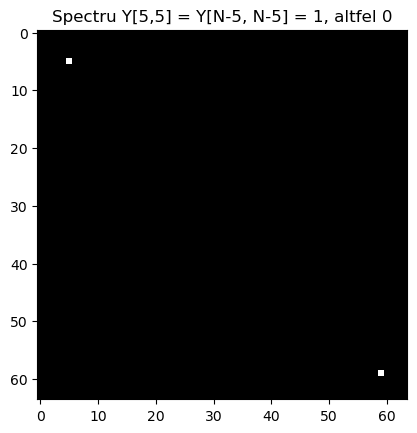

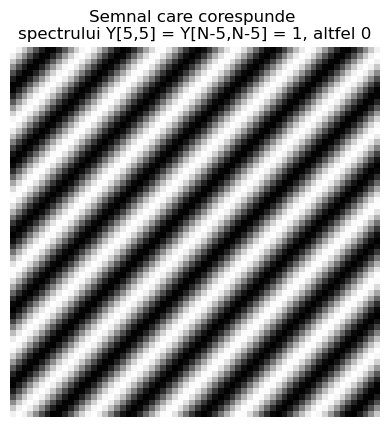

In [ ]:
# A CINCEA BULINA

Y = np.zeros((N, N))
Y[5,5] = 1
Y[N-5,N-5] = 1

plt.imshow(np.abs(Y), cmap='gray')
plt.title("Spectru Y[5,5] = Y[N-5, N-5] = 1, altfel 0")
# plt.axis('off')
plt.savefig("1_e_spectru.pdf")
plt.show()

x = np.fft.ifft2(Y)
x = np.real(x)

plt.imshow(x, cmap='gray')
plt.title("Semnal care corespunde \nspectrului Y[5,5] = Y[N-5,N-5] = 1, altfel 0")
plt.axis('off')
plt.savefig("1_e_semnal.pdf")
plt.show()

#COMENTARII:

# in Y am activat doar 2 binuri din spectrul 2D

# cum Y[m1, m2] = Y*[N1-m1, N2-m2] (AICI: Y[5,5] = Y*[N-5, N-5]), practic am activat o singura frecventa 2D, (m1, m2) = (5, 5)
# Asta inseamna ca in imaginea obtinuta cu ifft, 
#               m1 = 5 imi spune ca voi avea o variatie pe directia parcursa de n1 (pe linii, pe orizontala)
#               m2 = 5 imi spune ca voi avea variatie simultan si pe verticala, directie parcursa de n2
#               
#               => in imaginea reconstruita vad variatie pe diagonala

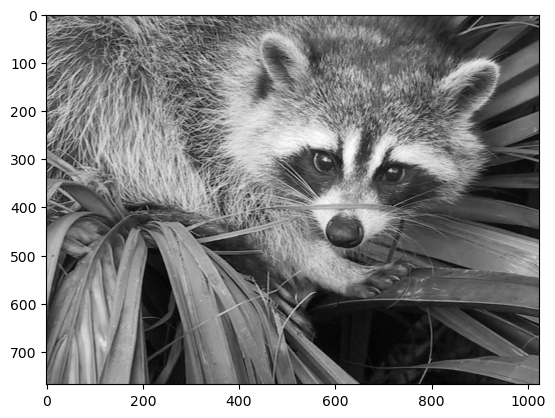

f_cut=0.005, SNR=9.73 dB
f_cut=0.006, SNR=10.33 dB


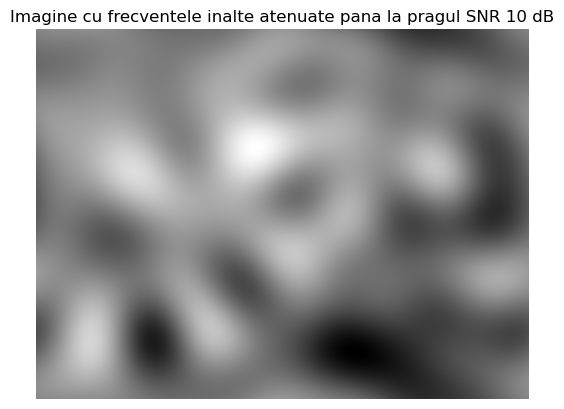

In [40]:
# Exercitiul 2

# Comprim imaginea cu ratonul prin atenuarea frecventelor inalte pana la un prag SNR autoimpus

def SNR(img_original, img_nou): #SNR intre imaginea origianala si cea comprimata
    numarator = np.sum(img_original**2)
    numitor = np.sum((img_original - img_nou)**2)
    return 10 * np.log10(numarator / numitor)


# IMAGINEA CU RATON      - - -  - - -  -  - -  - - - -  -  - - -  - - - - - -  - - - -  - - - -  - -  - - - -
x_raton = imageio.imread("racoon.png")
raton_gray = np.mean(x_raton, axis=2)

plt.imshow(raton_gray, cmap='gray')
plt.show()

# TF a IMAGINII CU RATON - - -  - - -  -  - -  - - - -  -  - - -  - - - - - -  - - - -  - - - -  - -  - - - -
Y = np.fft.fft2(raton_gray)
freq_db = 20 * np.log10(np.abs(Y)) #magnitudinea in decibeli / scara log pt a vedea mai bine

# plt.imshow(freq_db) #, cmap='gray')
# plt.title("Magnitudinea TF pentru img cu raton \n(scara logaritmica)")
# #plt.axis('off')
# plt.colorbar()
# plt.savefig("2_magnitudine_FT_raton_scara_log.pdf")
# plt.show()

# Compresia pana la pragul SNR autoimpus - - - -  - - - -  - - -  - - - - - - - - - - - - - - - - - - - - - - 

N1 = raton_gray.shape[0] #768
N2 = raton_gray.shape[1] #1024
# print(N1, N2)

fy = np.fft.fftfreq(N1)   #frecventele reale pe Oy pentru care am calculat FT       768 de frecvente
fx = np.fft.fftfreq(N2)   #                  pe Ox                                  1024 de frecvente                   
# print(fy, len(fy))
# print(fx, len(fx))

FX, FY = np.meshgrid(fx, fy) # FX = matrice cu fx replicat pe orizontala de [inaltimea_imaginii] ori 
                            # FY = matrice cu fy replicat pe verticala de [latimea_imaginii] ori
                            
# print(len(FX), len(FX[0])) #768 1024
# print(len(FY), len(FY[0])) #768 1024

# definesc o raza cu un capat in 0,0 care imi spune cat de mult ma indepartez de frecventa 0,0 , i.e. cat de mult cresc in frecventa

#MATRICEA CU RAZELE (DISTANTELE FATA DE 0,0):
radius = np.sqrt(FX**2 + FY**2)

f_cut = 0.005
SNR_tinta = 10

while True: # cresc succesiv raza pana la care pastrez frecentele pana ajung la SNR tinta
    
    masca = radius <= f_cut # masca in care memorez True pentru o frecventa pe care o pastrez si False pentru o frecventa pe care o tai
                            # tai frecventele care au distanta fata de frecventa 0,0 mai mare decat f_cut, deci tai frecventele inalte
                            
                            #Se pastreaza practic frecventele din interiorul a patru sferturi de cercuri corespunzand colturilor matricei 
                            #Acolo am frecventele mici, apropiate ca distanta L2 de frecventa (0,0)
    #print(masca)

    Y_low_pass = Y * masca #spectrul filtrat in care au ramas doar frecventele joase
    x_lp = np.real(np.fft.ifft2(Y_low_pass)) #imaginea reconstruita din spectrul filtrat
    
    snr_actual = SNR(raton_gray, x_lp)
    
    print(f"f_cut={f_cut:.3f}, SNR={snr_actual:.2f} dB")

    if snr_actual >= SNR_tinta:
        break
    f_cut += 0.001
    
plt.imshow(x_lp, cmap='gray')
plt.title(f"Imagine cu frecventele inalte atenuate pana la pragul SNR {SNR_tinta} dB")
plt.axis('off')
plt.savefig("2_imagine_filtrata.pdf")
plt.show()

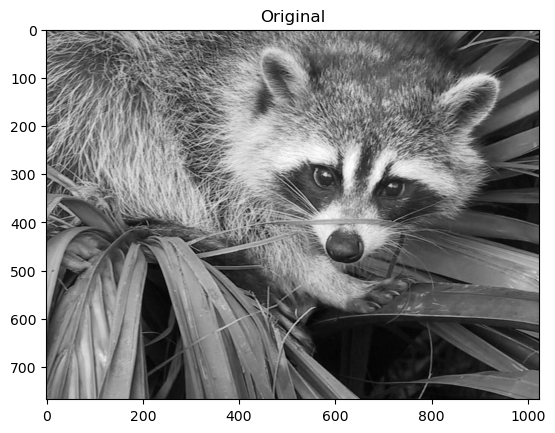

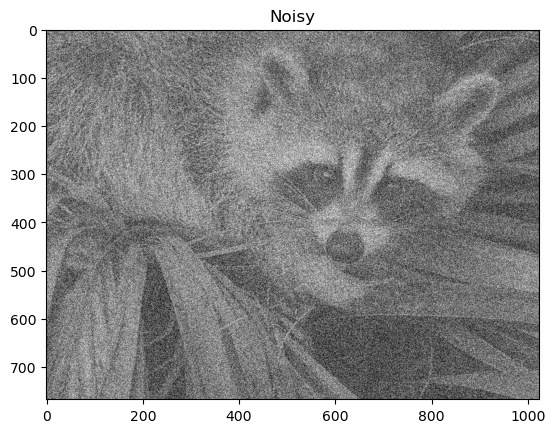

SNR inainte de filtrare:  0.5350511973759717
f_cut=0.005, SNR=9.73 dB
f_cut=0.015, SNR=12.55 dB
f_cut=0.025, SNR=13.80 dB
f_cut=0.035, SNR=14.34 dB


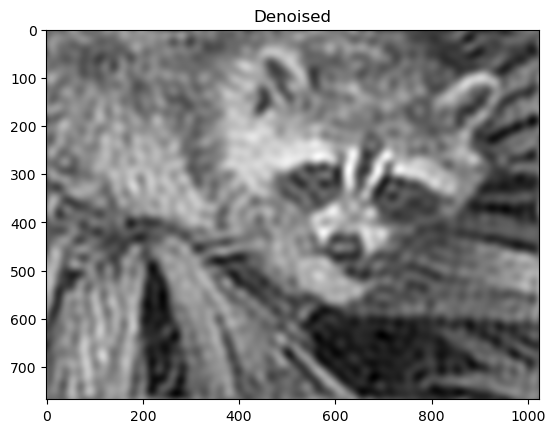

SNR dupa filtrarea zgomotului alb: 14.34420542137449


In [49]:
# Exerctiul 3 - eliminarea zgomotului alb
X = imageio.imread("racoon.png") # COLOR
pixel_noise = 200
X = np.mean(X, axis=2)          # GRI

noise = np.random.randint(-pixel_noise, high=pixel_noise+1, size=X.shape)
X_noisy = X + noise
plt.imshow(X, cmap=plt.cm.gray)
plt.title('Original')
plt.show()
plt.imshow(X_noisy, cmap=plt.cm.gray)
plt.title('Noisy')
plt.show()


snr_inainte = SNR(raton_gray, X_noisy)
print("SNR inainte de filtrare: ", snr_inainte)

Y_noisy = np.fft.fft2(X_noisy)


f_cut = 0.005
SNR_tinta = 14

while True: # cresc succesiv raza pana la care pastrez frecentele pana ajung la SNR tinta
    
    masca = radius <= f_cut # masca in care memorez True pentru o frecventa pe care o pastrez si False pentru o frecventa pe care o tai
                            # tai frecventele care au distanta fata de frecventa 0,0 mai mare decat f_cut, deci tai frecventele inalte
                            
                            #Se pastreaza practic frecventele din interiorul a patru sferturi de cercuri corespunzand colturilor matricei 
                            #Acolo am frecventele mici, apropiate ca distanta L2 de frecventa (0,0)
    #print(masca)

    Y_noisy_filtered = Y_noisy * masca
    x_denoised = np.real(np.fft.ifft2(Y_noisy_filtered))
    
    snr_actual = SNR(raton_gray, x_denoised)
    
    print(f"f_cut={f_cut:.3f}, SNR={snr_actual:.2f} dB")

    if snr_actual >= SNR_tinta:
        break
    f_cut += 0.01


plt.imshow(x_denoised, cmap=plt.cm.gray)
plt.title('Denoised')
plt.savefig("3_denoised.pdf")
plt.show()

snr_dupa_filtrare = SNR(raton_gray, x_denoised)
print("SNR dupa filtrarea zgomotului alb:", snr_dupa_filtrare)

